In [1]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [3]:
# f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
# print(f.read())

In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2008-2019.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,municipality,district,region,municipality_enc,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2008-06-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,6,22,2008,3,0.201299,0.979530,1.224647e-16,-1.000000,0.464723,-0.885456,-1.0,-1.836970e-16,510,0,0,0,0.337618,0.085178,-0.258586,-0.085178,0.352347,0.100392,-0.258073,-0.100392,0.110758,0.113585,0.021746,0.113585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,55.633333,96.800000,373.633333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2008-06-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,6,25,2008,3,-0.101168,-0.994869,1.224647e-16,-1.000000,0.120537,-0.992709,-1.0,-1.836970e-16,435,510,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,64.500000,88.900000,462.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2008-07-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,7,27,2008,3,0.201299,0.979530,-5.000000e-01,-0.866025,-0.120537,-0.992709,-1.0,-1.836970e-16,298,945,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,38.466667,58.666667,521.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2008-07-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,7,29,2008,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-0.354605,-0.935016,-1.0,-1.836970e-16,370,733,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.100000,1.333333,522.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2008-08-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,8,31,2008,3,0.201299,0.979530,-8.660254e-01,-0.500000,-0.568065,-0.822984,-1.0,-1.836970e-16,234,668,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,17.500000,32.033333,554.900000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0


In [6]:
# dataset = dataset.query('month >= 6 & month <= 10')
# dataset.reset_index(inplace=True, drop=True)

dataset.rename(columns={"municipality": "lau1", "district": "nuts3", "region" : "nuts2", "municipality_enc" : "lau1_id"}, inplace=True)

In [7]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,1907,1,1908,8.32%
1,2009,1902,6,1908,8.32%
2,2010,1901,7,1908,8.32%
3,2011,1897,11,1908,8.32%
4,2012,1877,34,1911,8.34%
5,2013,1880,29,1909,8.33%
6,2014,1906,2,1908,8.32%
7,2015,1907,1,1908,8.32%
8,2016,1896,12,1908,8.32%
9,2017,1892,17,1909,8.33%


In [8]:
feature_list = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns.tolist()

In [9]:
#Use all data for training

ft_importance = pd.DataFrame()

for feature in feature_list:
    print(f"Training without feature: '{feature}'")
    X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
    y_train = dataset['case']

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)

    imputer = KNNImputer()
    X_train = imputer.fit_transform(X_train)

    try:
        class_0_counts = y_train.value_counts()[0]
    except KeyError:
        class_0_counts = 0
    try:
        class_1_counts = y_train.value_counts()[1]
    except KeyError:
        class_1_counts = 0
        
    if (near_u != 0):
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
        X_train, y_train = nm.fit_resample(X_train, y_train)
    
    if (smote != 0):
        class_0_counts = y_train.value_counts()[0]
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_train)

    loss = log_loss(y_train, probabilities)

    ft_importance = ft_importance.append({'Feature': feature,
                                          'Loss': loss}, ignore_index = True)

Training without feature: 'x'
Training without feature: 'y'
Training without feature: 'lau1_id'
Training without feature: 'area'
Training without feature: 'pop_1'
Training without feature: 'pop_2'
Training without feature: 'pop_3'
Training without feature: 'pop_total'
Training without feature: 'eq_distance'
Training without feature: 'day'
Training without feature: 'month'
Training without feature: 'week'
Training without feature: 'year'
Training without feature: 'season'
Training without feature: 'day_sin'
Training without feature: 'day_cos'
Training without feature: 'month_sin'
Training without feature: 'month_cos'
Training without feature: 'week_sin'
Training without feature: 'week_cos'
Training without feature: 'season_sin'
Training without feature: 'season_cos'
Training without feature: 'mosq_pred'
Training without feature: 'mosq_prev_30d'
Training without feature: 'case_prev_p'
Training without feature: 'case_prev_m'
Training without feature: 'ndvi'
Training without feature: 'ndmi

In [10]:
# Split in train and test

# ft_importance = pd.DataFrame()

# for feature in feature_list:
#     print(f"Training without feature: '{feature}'")
#     X = dataset.select_dtypes(exclude=['object']).drop(columns = ['case', feature])
#     y = dataset['case']

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify = y, random_state = 0)

#     scaler = MinMaxScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     imputer = KNNImputer()
#     X_train = imputer.fit_transform(X_train)
#     X_test = imputer.transform(X_test)

#     try:
#         class_0_counts = y_train.value_counts()[0]
#     except KeyError:
#         class_0_counts = 0
#     try:
#         class_1_counts = y_train.value_counts()[1]
#     except KeyError:
#         class_1_counts = 0
        
#     if (near_u != 0):
#         nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
#         X_train, y_train = nm.fit_resample(X_train, y_train)
    
#     if (smote != 0):
#         class_0_counts = y_train.value_counts()[0]
#         sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
#         X_train, y_train = sm.fit_resample(X_train, y_train)

#     w0,w1 = calculate_weights(y_train)

#     model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
#     model.fit(X_train, y_train)

#     probabilities_test = model.predict_proba(X_test)

#     loss = log_loss(y_test, probabilities_test)

#     ft_importance = ft_importance.append({'Feature': feature,
#                                           'Loss': loss}, ignore_index = True)

In [11]:
ft_importance.sort_values(by=['Loss'], ascending=True, inplace=True)

In [12]:
losses = ft_importance['Loss']
shp = losses.shape[0]
losses = losses.to_numpy().reshape(1,shp)

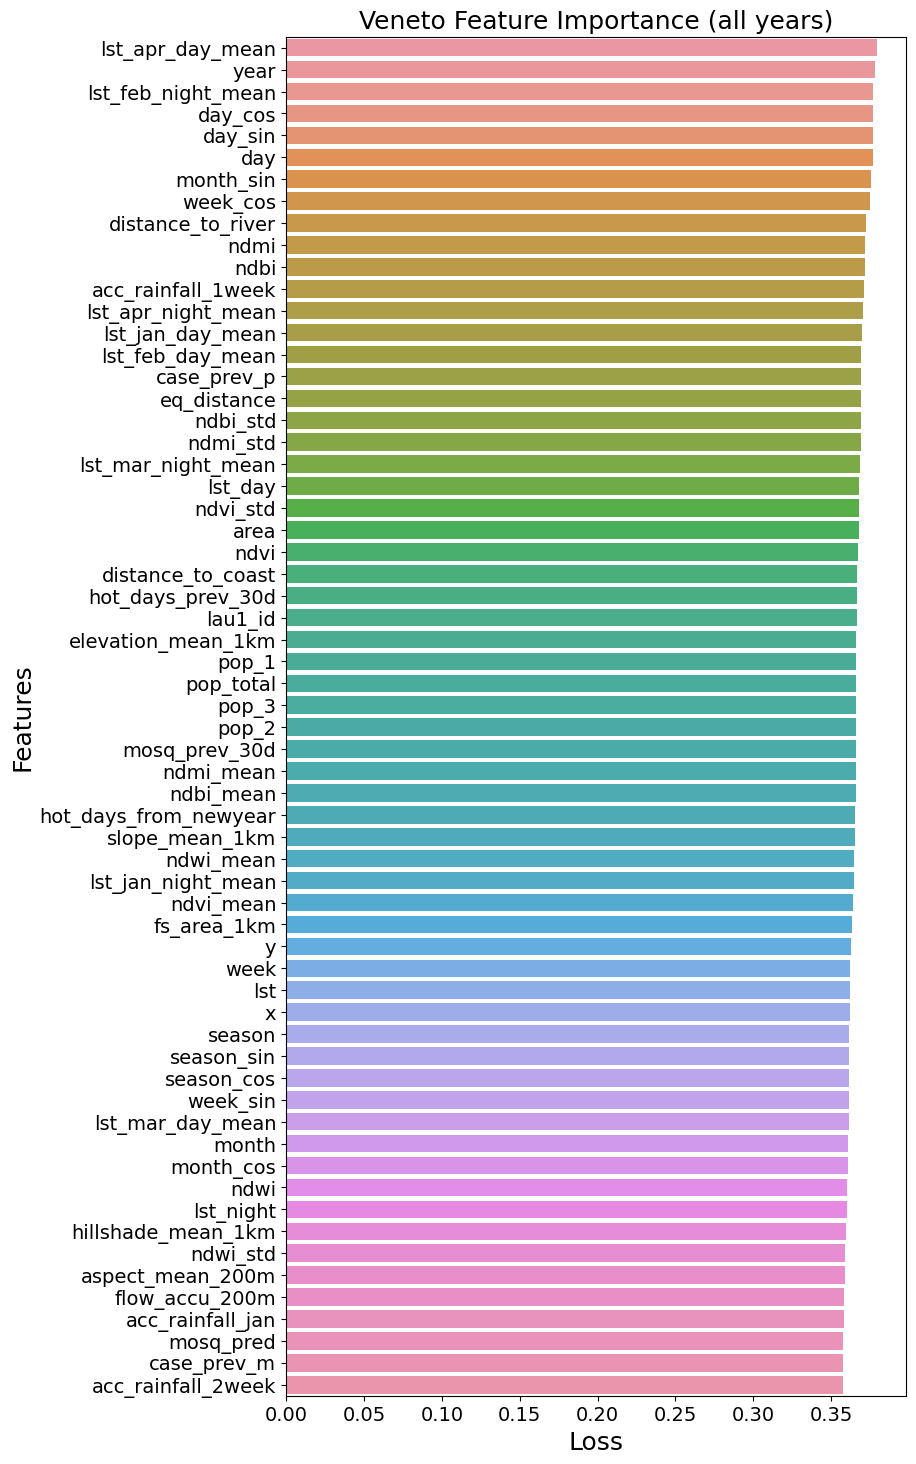

In [13]:
plot_feature_importance(losses, ft_importance['Feature'], x_label = 'Loss', title = f'{NUTS2} Feature Importance (all years)', title_size=18)